# camel beauty assessor — v1 against v2

v2 is the same photographs re-annotated: one camel per image, wider `Wide_body` boxes, corrected
mislabels, and polygons replaced by boxes. every model is re-run on it under the settings it had in
v1, so a difference here is the annotations and nothing else.

section 2 works before any v2 training has happened. section 3 onward waits for `results/v2/`.

## 1. setup

### 1.1 imports

In [1]:
import os
import pathlib
import collections
import statistics

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### 1.2 paths

In [2]:
root = pathlib.Path.cwd()
versions = ["v1", "v2"]

canon = ["Camel", "High_withers", "Large-head", "Large-lips", "Large-nose",
         "Large_hump", "Long-legs", "Long-neck", "Wide_body"]
traits = [c for c in canon if c != "Camel"]

### 1.3 display options

In [3]:
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

pd.set_option("display.width", 250)
pd.set_option("display.max_columns", 60)
pd.set_option("display.max_rows", 300)
pd.set_option("display.expand_frame_repr", False)

## 2. what changed in the data

reads the labels straight off disk, so this runs before any training.

In [4]:
def label_files(version):
    base = root / "dataset" / version
    merged = base / "merged" / "labels"
    if merged.is_dir() and any(merged.glob("*.txt")):
        return sorted(merged.glob("*.txt")), "merged"
    return sorted(base.glob("raw/*/train/labels/*.txt")), "raw export"


def describe(version):
    files, origin = label_files(version)
    assert files, f"no labels found for {version}"

    lines = polys = mixed = 0
    per_class = collections.Counter()
    camels, areas = [], collections.defaultdict(list)

    for f in files:
        rows = [l.split() for l in f.read_text(encoding="utf-8").splitlines() if l.strip()]
        shapes = {len(r) == 5 for r in rows}
        if shapes == {True, False}:
            mixed += 1
        n_cam = 0
        for r in rows:
            lines += 1
            name = canon[int(r[0])]
            per_class[name] += 1
            if int(r[0]) == 0:
                n_cam += 1
            if len(r) == 5:
                areas[name].append(float(r[3]) * float(r[4]))
            else:
                polys += 1
                xs, ys = [float(v) for v in r[1::2]], [float(v) for v in r[2::2]]
                areas[name].append((max(xs) - min(xs)) * (max(ys) - min(ys)))
        camels.append(n_cam)

    return {"origin": origin, "images": len(files), "annotations": lines,
            "polygon_lines": polys, "mixed_files": mixed,
            "camels_per_image": round(sum(camels) / len(camels), 2),
            "max_camels": max(camels), "multi_camel_images": sum(1 for c in camels if c > 1),
            "per_class": per_class, "areas": areas}


facts = {v: describe(v) for v in versions}
overview = pd.DataFrame({v: {k: f[k] for k in
                             ("origin", "images", "annotations", "polygon_lines", "mixed_files",
                              "camels_per_image", "max_camels", "multi_camel_images")}
                         for v, f in facts.items()})
overview

,v1,v2
origin,merged,merged
images,196,195
annotations,1065,931
polygon_lines,307,0
mixed_files,21,0
camels_per_image,1.6,1.0
max_camels,13,1
multi_camel_images,38,0


### 2.1 annotations per class

In [5]:
per_class = pd.DataFrame({v: pd.Series(f["per_class"]) for v, f in facts.items()}).reindex(canon).fillna(0).astype(int)
per_class["change"] = per_class.v2 - per_class.v1
per_class["pct"] = (100 * per_class.change / per_class.v1.replace(0, np.nan)).round(1)
per_class

,v1,v2,change,pct
Camel,314,195,-119,-37.9
High_withers,89,92,3,3.4
Large-head,63,58,-5,-7.9
Large-lips,95,95,0,0.0
Large-nose,86,85,-1,-1.2
Large_hump,84,91,7,8.3
Long-legs,100,103,3,3.0
Long-neck,141,115,-26,-18.4
Wide_body,93,97,4,4.3


### 2.2 how big each trait box is now

In [6]:
size = pd.DataFrame({
    v: {c: round(100 * statistics.median(f["areas"][c]), 3) if f["areas"][c] else np.nan for c in canon}
    for v, f in facts.items()})
size.columns = [f"{c}_area_pct" for c in size.columns]
size["x_bigger"] = (size.v2_area_pct / size.v1_area_pct).round(2)
size["px_at_640_v1"] = (np.sqrt(size.v1_area_pct / 100) * 640).round().astype("Int64")
size["px_at_640_v2"] = (np.sqrt(size.v2_area_pct / 100) * 640).round().astype("Int64")
size.reindex(canon)

,v1_area_pct,v2_area_pct,x_bigger,px_at_640_v1,px_at_640_v2
Camel,32.597,53.368,1.64,365,468
High_withers,1.898,1.392,0.73,88,76
Large-head,2.781,2.400,0.86,107,99
Large-lips,0.268,0.267,1.00,33,33
Large-nose,0.332,0.323,0.97,37,36
Large_hump,3.171,3.076,0.97,114,112
Long-legs,5.182,6.224,1.20,146,160
Long-neck,4.225,4.668,1.10,132,138
Wide_body,0.766,1.135,1.48,56,68


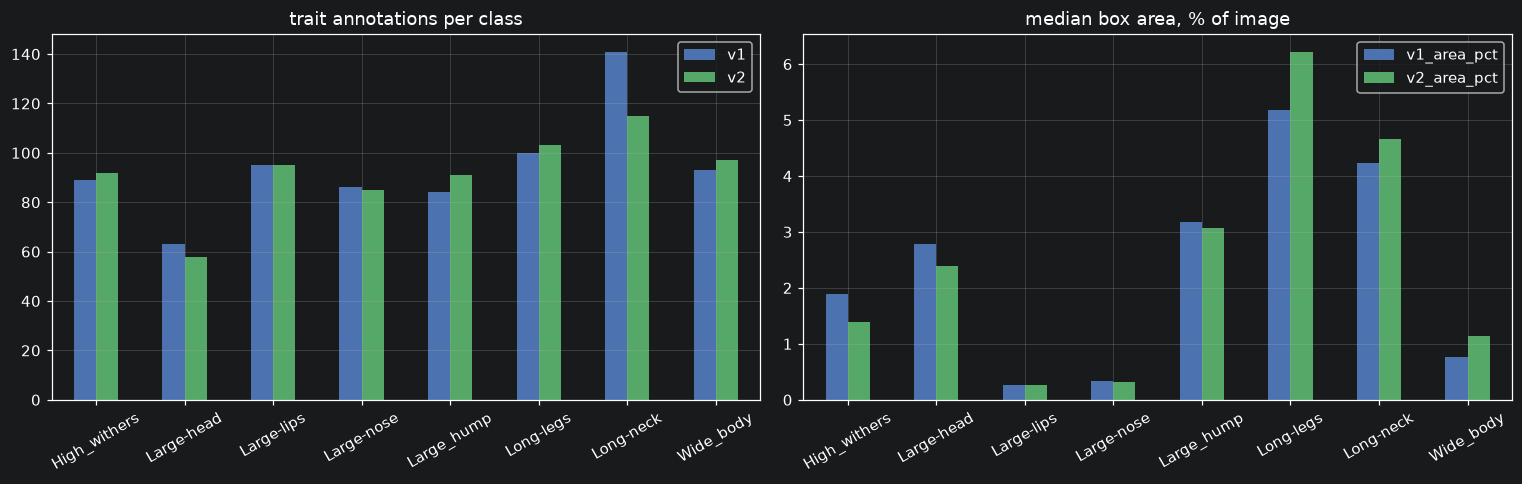

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
per_class.loc[traits, ["v1", "v2"]].plot(kind="bar", ax=axes[0], color=["#4c72b0", "#55a868"])
axes[0].set_title("trait annotations per class")
axes[0].set_xlabel("")

size.loc[traits, ["v1_area_pct", "v2_area_pct"]].plot(kind="bar", ax=axes[1], color=["#4c72b0", "#55a868"])
axes[1].set_title("median box area, % of image")
axes[1].set_xlabel("")

for ax in axes:
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

## 3. what changed in the results

In [8]:
SOURCES = ("experiments.csv", "freezing.csv", "learning_rate.csv")
KEEP = ["mAP50", "mAP50_95", "precision", "recall"]


def load_results(version):
    d = root / "results" / version
    frames = []
    for f in SOURCES:
        p = d / f
        if not p.exists():
            continue
        t = pd.read_csv(p)
        if {"run", "mAP50_95"} <= set(t.columns):
            frames.append(t[["run"] + [c for c in KEEP if c in t.columns]])
    if not frames:
        return None
    return pd.concat(frames, ignore_index=True).drop_duplicates("run", keep="last").set_index("run")


scores = {v: load_results(v) for v in versions}
for v, s in scores.items():
    print(f"  {v}: {0 if s is None else len(s)} runs with test scores")

ready = all(s is not None for s in scores.values())
if not ready:
    print()
    print("v2 has no results yet. run baseline, fine-tuning, freezing and learning_rate with")
    print('VERSION = "v2", then re-run from here.')

  v1: 29 runs with test scores
  v2: 29 runs with test scores


In [9]:
assert ready, "v2 results are missing, see the message above"

both = scores["v1"].join(scores["v2"], how="inner", lsuffix="_v1", rsuffix="_v2")
both["delta"] = (both.mAP50_95_v2 - both.mAP50_95_v1).round(4)
both["pct"] = (100 * both.delta / both.mAP50_95_v1).round(1)

compare = both[["mAP50_95_v1", "mAP50_95_v2", "delta", "pct",
                "precision_v1", "precision_v2", "recall_v1", "recall_v2"]]
compare.sort_values("delta", ascending=False)

,mAP50_95_v1,mAP50_95_v2,delta,pct,precision_v1,precision_v2,recall_v1,recall_v2
run,,,,,,,,
e5-hires,0.2947,0.4261,0.1314,44.6,0.5757,0.7454,0.6886,0.7955
e2-rot45,0.2901,0.4164,0.1263,43.5,0.8055,0.6669,0.4670,0.7762
f16-rot45-gray,0.2200,0.3407,0.1207,54.9,0.4834,0.5637,0.5566,0.6444
b3-aug-gray,0.2986,0.4164,0.1178,39.5,0.6857,0.7169,0.5800,0.7484
b1-rgb,0.3206,0.4384,0.1178,36.7,0.7073,0.7546,0.6485,0.7915
f16-plain-gray,0.2471,0.3645,0.1174,47.5,0.5178,0.6459,0.5631,0.6230
e1-gray,0.3091,0.4259,0.1168,37.8,0.5837,0.7428,0.7044,0.7562
b2-aug,0.2623,0.3747,0.1124,42.9,0.5225,0.7186,0.5998,0.5852
b0-scratch,0.2146,0.3199,0.1053,49.1,0.4902,0.6512,0.4359,0.5645


### 3.1 the headline

In [10]:
better = int((both.delta > 0).sum())
print(f"{better} of {len(both)} models improved on v2, {len(both) - better} did not")
print(f"median change {both.delta.median():+.4f} mAP50-95   mean {both.delta.mean():+.4f}")
print()

for v in versions:
    s = scores[v]
    top = s.mAP50_95.idxmax()
    print(f"best on {v}: {top:<18} mAP50 {s.loc[top, 'mAP50']:.4f}   mAP50-95 {s.loc[top, 'mAP50_95']:.4f}")

gain = scores["v2"].mAP50_95.max() - scores["v1"].mAP50_95.max()
print()
print(f"best model overall moved {gain:+.4f} mAP50-95 from re-annotation alone")

29 of 29 models improved on v2, 0 did not
median change +0.0874 mAP50-95   mean +0.0928

best on v1: e0-nomosaic        mAP50 0.6710   mAP50-95 0.3233
best on v2: b1-rgb             mAP50 0.7983   mAP50-95 0.4384

best model overall moved +0.1151 mAP50-95 from re-annotation alone


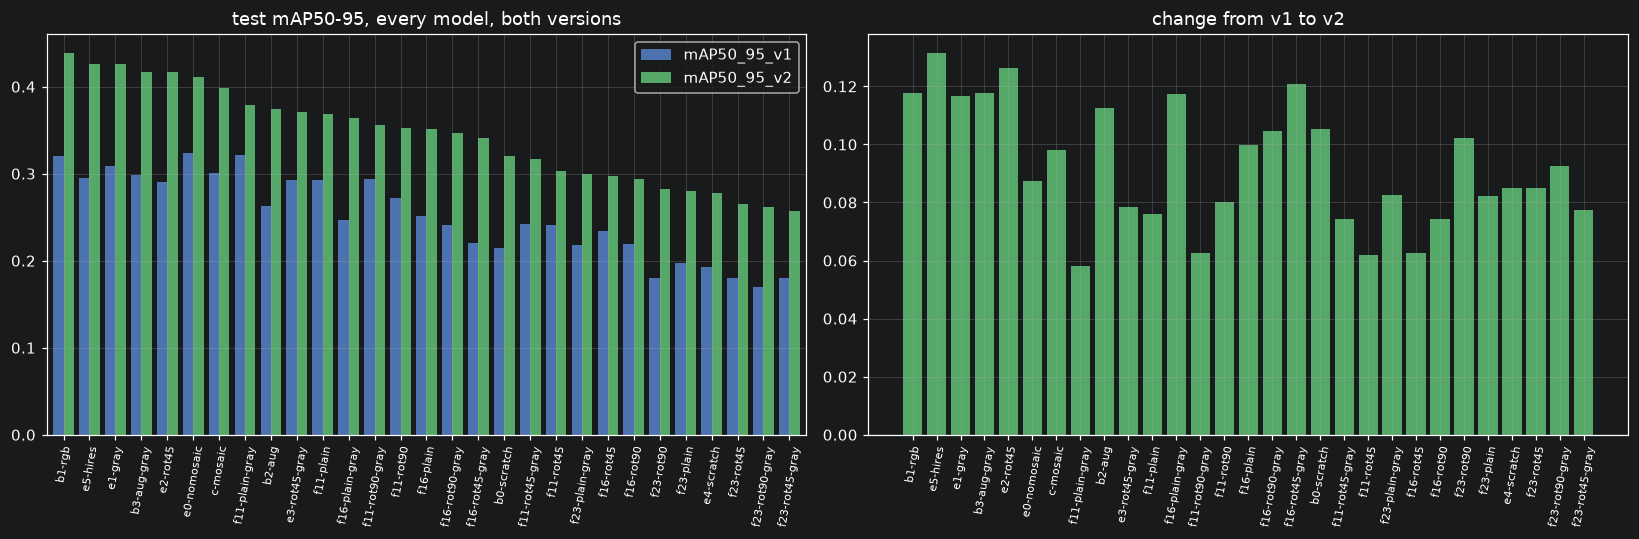

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ordered = compare.sort_values("mAP50_95_v2", ascending=False)
ordered[["mAP50_95_v1", "mAP50_95_v2"]].plot(kind="bar", ax=axes[0], color=["#4c72b0", "#55a868"], width=0.8)
axes[0].set_title("test mAP50-95, every model, both versions")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=80, labelsize=7)

colours = ["#55a868" if d > 0 else "#c44e52" for d in ordered.delta]
axes[1].bar(range(len(ordered)), ordered.delta, color=colours)
axes[1].axhline(0, color="grey", lw=0.8)
axes[1].set_xticks(range(len(ordered)))
axes[1].set_xticklabels(ordered.index, rotation=80, fontsize=7)
axes[1].set_title("change from v1 to v2")

plt.tight_layout()
plt.show()

### 3.2 by family

In [12]:
def family(name):
    if name.startswith("b"):
        return "baseline"
    if name.startswith("e"):
        return "fine-tuning"
    if name.startswith(("f", "c-")):
        return "freezing"
    return "learning rate"


fam = compare.assign(family=[family(i) for i in compare.index])
fam.groupby("family")[["mAP50_95_v1", "mAP50_95_v2", "delta"]].agg(
    ["mean", "max"]).round(4)

mAP50_95_v1         mAP50_95_v2           delta        
                   mean     max        mean     max    mean     max
family                                                             
baseline         0.2740  0.3206      0.3873  0.4384  0.1133  0.1178
fine-tuning      0.2837  0.3233      0.3879  0.4261  0.1042  0.1314
freezing         0.2370  0.3212      0.3219  0.3984  0.0849  0.1207

### 3.3 per class, best model of each version

the classes the re-annotation targeted are `Wide_body` and anything that was previously drawn
around the wrong object.

In [13]:
def per_class_table(version):
    for f in ("per_class_experiments.csv", "per_class_test.csv", "per_class_frozen.csv"):
        p = root / "results" / version / f
        if p.exists():
            t = pd.read_csv(p, header=[0, 1], index_col=0)
            cols = [c for c in t.columns if c[1] == "mAP50_95"]
            if cols:
                return t[cols].iloc[:, 0].rename(version)
    return None


a, b = per_class_table("v1"), per_class_table("v2")
if a is None or b is None:
    print("per-class files missing for one version, skipping")
else:
    pc = pd.concat([a, b], axis=1).reindex(canon)
    pc["delta"] = (pc.v2 - pc.v1).round(3)
    display(pc)

,v1,v2,delta
cls,,,
Camel,0.634,0.881,0.247
High_withers,0.297,0.318,0.021
Large-head,0.346,0.333,-0.013
Large-lips,0.327,0.444,0.117
Large-nose,0.301,0.290,-0.011
Large_hump,0.156,0.366,0.210
Long-legs,0.346,0.346,0.000
Long-neck,0.456,0.593,0.137
Wide_body,0.047,0.127,0.080


## 4. saved

In [14]:
out = root / "results"
compare.to_csv(out / "version_comparison.csv")
overview.to_csv(out / "version_data_overview.csv")
per_class.to_csv(out / "version_per_class_annotations.csv")
print("written to", out)

written to E:\PycharmProjects\camel-beauty-assessor\results
